In [1]:
import glob
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil

In [2]:
def read_data_path(path):
    files = glob.glob(f'{path}/**/*.jpg', recursive=True)
    return files

In [3]:
files = read_data_path(path="C:/Non-work/ML/Nepali-liscence-number-recognition/Dataset/images")

In [4]:
# # Initialize a dictionary to store the number of files in each class
# def get_class_count(image_path_list):
#     class_counts = {}

#     for file_path in image_path_list:
#         class_name = os.path.basename(os.path.dirname(file_path))
#         if class_name in class_counts:
#             class_counts[class_name] += 1
#         else:
#             class_counts[class_name] = 1
#     return class_counts


In [5]:
# Initialize a dictionary to store the number of files in each class
def make_data_csv(image_path_list):
    class_counts = {}
    labels = []

    for file_path in image_path_list:
        class_name = os.path.basename(os.path.dirname(file_path))
        labels.append(class_name)
    data_dict = {"Images": image_path_list, "Labels": labels}
    dataset = pd.DataFrame(data_dict)
        
    return dataset


In [6]:
# class_counts = get_class_count(image_path_list=files)

In [7]:
dataset_df = make_data_csv(image_path_list=files)

In [8]:
dataset_df

,Images,Labels
0,C:/Non-work/ML/Nepali-liscence-number-recognit...,0
1,C:/Non-work/ML/Nepali-liscence-number-recognit...,0
2,C:/Non-work/ML/Nepali-liscence-number-recognit...,0
3,C:/Non-work/ML/Nepali-liscence-number-recognit...,0
4,C:/Non-work/ML/Nepali-liscence-number-recognit...,0
...,...,...
2028,C:/Non-work/ML/Nepali-liscence-number-recognit...,pa
2029,C:/Non-work/ML/Nepali-liscence-number-recognit...,pa
2030,C:/Non-work/ML/Nepali-liscence-number-recognit...,pa
2031,C:/Non-work/ML/Nepali-liscence-number-recognit...,pa


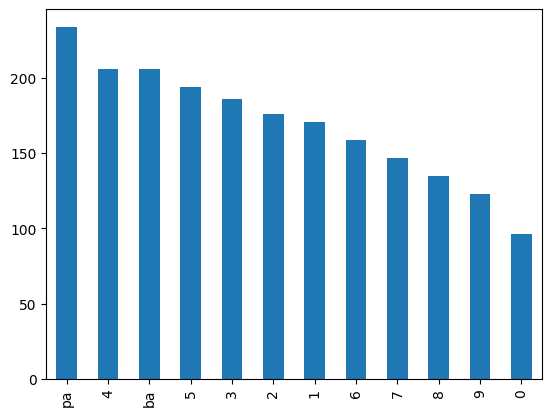

In [9]:
classes = dataset_df.Labels.value_counts().plot(kind='bar')

In [10]:
# plt.bar(class_counts.keys(), class_counts.values())
# plt.title('Class Counts')
# plt.xlabel('Labels')
# plt.ylabel('Counts')
# plt.show()

In [11]:
def read_images(image_path, size=()):
    image = Image.open(image_path)
    if len(size)>0:
        image = image.resize(size)
    return image    

In [12]:
image_sample = read_images("./Dataset/images\\4\\149.jpg")

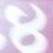

In [13]:
image_sample

In [14]:
# image_array = np.asarray(image_sample)

In [15]:
# image_array.shape

In [16]:
import torch
import torchvision.transforms as T

In [17]:
def change_color(image_path, brightness=.5, hue=.3):
    image = read_images(image_path)
    jitter = T.ColorJitter(brightness=brightness, hue=hue)
    jitted_imgs = jitter(image)
    return jitted_imgs

In [18]:
classes = dict(dataset_df.Labels.value_counts())
highest_label_count = max(classes.values())
highest_label_count

234

In [19]:
def augument_dataset():
    augumented_path = "C:/Non-work/ML/Nepali-liscence-number-recognition/Dataset/augumented"
    if not os.path.exists(augumented_path):
        os.makedirs(augumented_path)
    for key, value in classes.items():
        matched_label = dataset_df.loc[dataset_df["Labels"] == key]
        present_label_count = len(matched_label)
        for index, row in matched_label.iterrows():
            src_path = row["Images"]
    #         print(src_path)
            filename = os.path.basename(src_path)
            class_name = key
            dst_path = augumented_path+ "/" + class_name + "/" + filename
            if not os.path.exists(augumented_path+ "/" + class_name):
                os.makedirs(augumented_path+ "/" + class_name)
            shutil.copy(src_path, dst_path)

            brightness_factor = [.3,.4,.5]
            for i, brightness in enumerate(brightness_factor):
                if present_label_count< highest_label_count:
    #                 print("src file   ", src_path)
                    change_image = change_color(image_path=src_path, brightness=brightness)
                    new_path = augumented_path +"/"+str(class_name) + "/" + str(i) + filename 
    #                 print("new path   ", new_path)
                    change_image.save(new_path)
    #                 change_image.save(f"{augumented_path}/{class_name}/{i}{filename}")
                    present_label_count +=1
    #                 print(present_label_count)


In [20]:
# X=dataset_df["Images"]
# y=dataset_df["Labels"]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)

In [21]:
# data_dict = {"Images":X_test, "Labels":y_test}
# test_data = pd.DataFrame(data_dict)

In [23]:
augumented_path = "C:/Non-work/ML/Nepali-liscence-number-recognition/Dataset/augumented"
augumented_files = read_data_path(path=augumented_path)
aug_dataset_df = make_data_csv(image_path_list=augumented_files)

In [24]:
aug_dataset_df.Labels.value_counts()

pa    234
4     231
ba    231
1     230
2     230
3     230
5     230
6     229
7     229
8     229
0     224
9     219
Name: Labels, dtype: int64

In [25]:
def make_greyscale(image_path):
    gray_img = T.Grayscale()(image_path)
    return gray_img

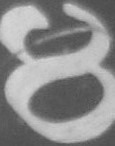

In [26]:
sample_img = read_images("./Dataset/augumented\\4\\101.jpg")
sample_gray = make_greyscale(sample_img)
sample_gray

In [29]:
X = aug_dataset_df["Images"]
y = aug_dataset_df["Labels"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [30]:
train_df = pd.DataFrame({"Images": X_train, "Labels":y_train})
test_df = pd.DataFrame({"Images": X_test, "Labels":y_test})

In [33]:
train_df.Labels.value_counts()

pa    187
4     185
ba    185
5     184
2     184
3     184
1     184
6     183
7     183
8     183
0     179
9     175
Name: Labels, dtype: int64

In [32]:
len(test_df)

550

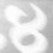

In [47]:
image_sample.convert("L")